In [1]:
# STEP 1: Install and import required libraries
!pip install kagglehub --quiet
!pip install seaborn matplotlib pandas numpy opencv-python --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Move your kaggle.json to ~/.kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
import kagglehub

dataset_slug = "imsparsh/flowers-dataset"
dataset_path = kagglehub.dataset_download(dataset_slug)
print(f"Dataset downloaded to: {dataset_path}")


Using Colab cache for faster access to the 'flowers-dataset' dataset.
Dataset downloaded to: /kaggle/input/flowers-dataset


In [4]:
import os

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")


flowers-dataset/
    sample_submission.csv
    Testing_set_flower.csv
    LICENSE.txt
    test/
        Image_747.jpg
        Image_561.jpg
        Image_345.jpg
    train/
        dandelion/
            16242239484_51286673af.jpg
            5716633491_55e6f02645_n.jpg
            13651218133_b6eb8e7ed2_m.jpg
        daisy/
            8882282142_9be2524d38_m.jpg
            19280272025_57de24e940_m.jpg
            5133243796_44de429de5_m.jpg
        sunflower/
            8249000137_eddfffa380_n.jpg
            16143151468_4f3c033e33.jpg
            14646279002_9cdf97be97_n.jpg
        tulip/
            8757486380_90952c5377.jpg
            8712230357_1298b8513b.jpg
            4590702749_e1df8e0c1b.jpg
        rose/
            6108118824_5b0231a56d.jpg
            16078501836_3ac067e18a.jpg
            13264214185_d6aa79b3bd.jpg


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
from PIL import Image

# Define dataset paths
base_path = "/kaggle/input/flowers-dataset"
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)


Train directory: /kaggle/input/flowers-dataset/train
Test directory: /kaggle/input/flowers-dataset/test


In [6]:
import os

train_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        train_counts[class_name] = num_images

train_counts


{'dandelion': 646, 'daisy': 501, 'sunflower': 495, 'tulip': 607, 'rose': 497}

In [7]:
import pandas as pd

df_train_counts = pd.DataFrame(list(train_counts.items()), columns=["Class", "Train_Images"])
df_train_counts["Train_Images"] = df_train_counts["Train_Images"].astype(int)
df_train_counts = df_train_counts.sort_values("Train_Images", ascending=False)
df_train_counts


,Class,Train_Images
0,dandelion,646
3,tulip,607
1,daisy,501
4,rose,497
2,sunflower,495


In [8]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_train_counts)

https://docs.google.com/spreadsheets/d/1q-3CaEtf-cmulTocd7hFGBAyffWFgemO4YMTVQhiW3Q/edit#gid=0


In [10]:
total_train = sum(train_counts.values())
total_test = len([f for f in os.listdir(test_dir) if f.endswith('.jpg') or f.endswith('.png')])
total_images = total_train + total_test

print(f" Total training images: {total_train}")
print(f" Total testing images: {total_test}")
print(f" Total number of images in dataset: {total_images}")


 Total training images: 2746
 Total testing images: 924
 Total number of images in dataset: 3670


**CLASS IMBALANCE - CHECK**

/tmp/ipython-input-6916605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train_counts, x="Class", y="Train_Images", palette="viridis")


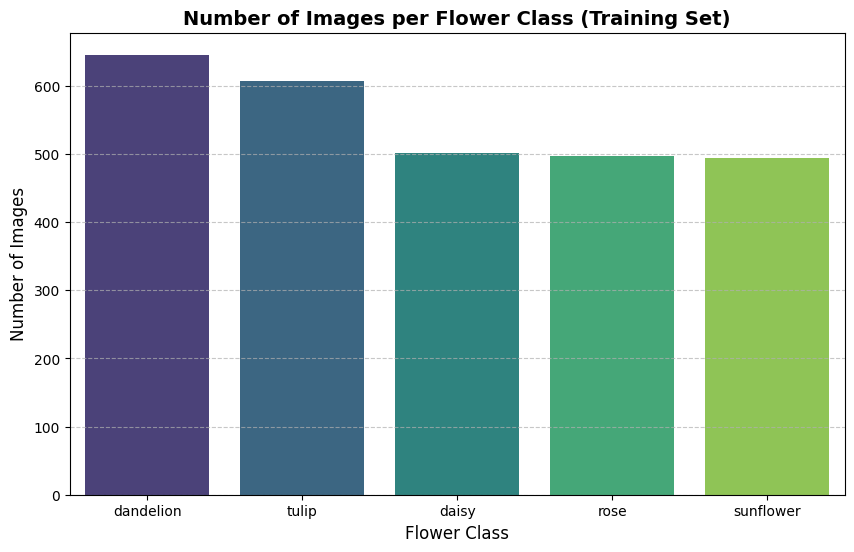

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=df_train_counts, x="Class", y="Train_Images", palette="viridis")
plt.title("Number of Images per Flower Class (Training Set)", fontsize=14, weight='bold')
plt.xlabel("Flower Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-200065095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=df_train_counts, x="Class", y="Train_Images", palette="coolwarm")


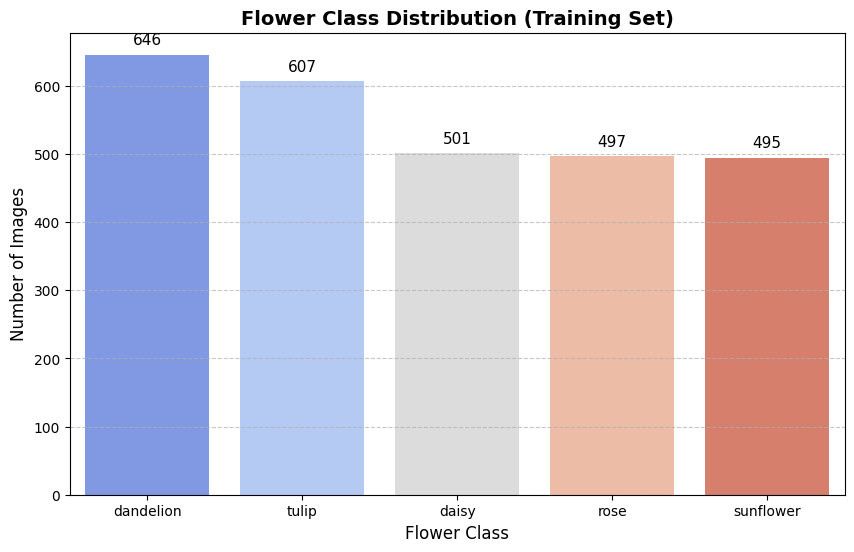

In [12]:
plt.figure(figsize=(10,6))
bar_plot = sns.barplot(data=df_train_counts, x="Class", y="Train_Images", palette="coolwarm")

for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                      textcoords='offset points')

plt.title("Flower Class Distribution (Training Set)", fontsize=14, weight='bold')
plt.xlabel("Flower Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [17]:
# Prepare data
labels = df_train_counts["Class"]
sizes = df_train_counts["Train_Images"]

# Define colors (optional — for aesthetic consistency)
colors = sns.color_palette("Set2", len(labels))





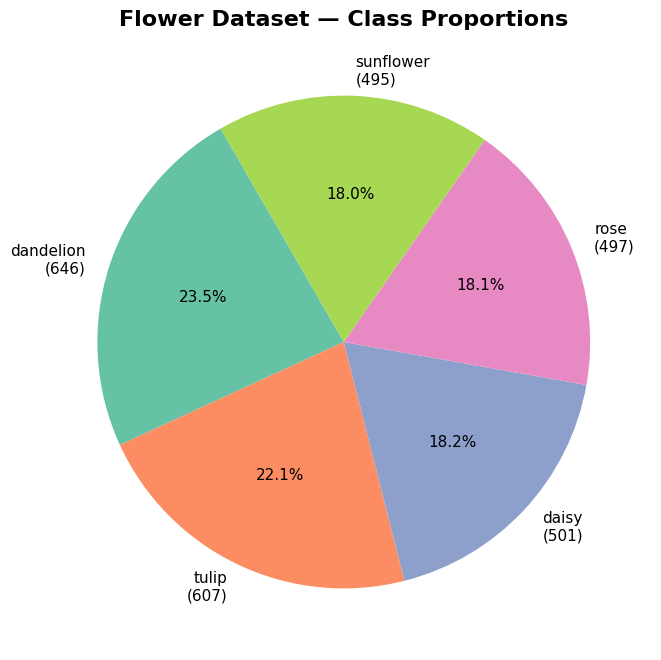

In [18]:
plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=[f"{label}\n({count})" for label, count in zip(labels, sizes)],
    autopct='%1.1f%%',
    startangle=120,
    colors=colors,
    textprops={'fontsize': 11}
)

plt.title("Flower Dataset — Class Proportions", fontsize=16, weight='bold')
plt.show()


**Class Distribution Analysis**

The bar plot shows the number of training images per flower category. The dataset is fairly balanced, with a slight class imbalance — dandelion (646) and tulip (607) have the most images, while sunflower (495) has the fewest. Although the difference is not severe, it may introduce a small bias toward the majority classes. This can be addressed later through techniques like **data augmentation** or **class-weighted loss** during model training.

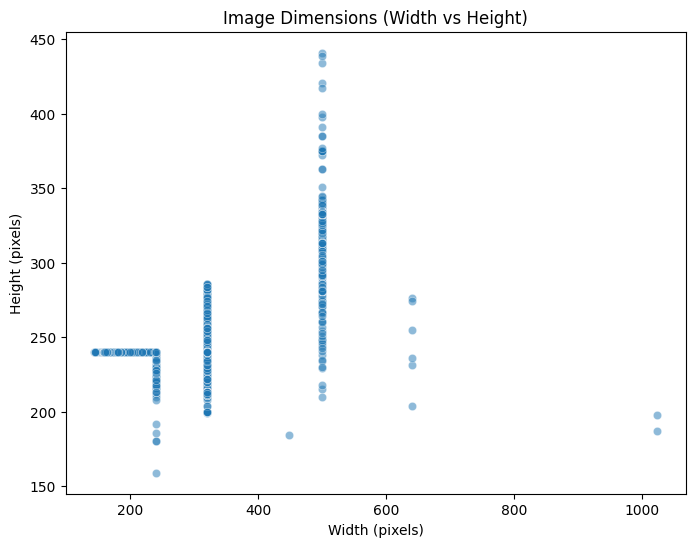

,Width,Height
count,2746.000000,2746.000000
mean,362.329570,267.994538
std,116.982811,47.883758
min,143.000000,159.000000
25%,320.000000,240.000000
50%,320.000000,240.000000
75%,500.000000,332.000000
max,1024.000000,441.000000


In [19]:
from PIL import Image

image_sizes = []
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        with Image.open(img_path) as img:
            image_sizes.append(img.size)  # (width, height)

# Convert to DataFrame
import pandas as pd
sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=sizes_df, x='Width', y='Height', alpha=0.5)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

sizes_df.describe()


**Image Dimension Analysis**

The scatter plot shows that image sizes in the dataset vary widely, indicating that the images are not uniform in resolution. The average width is around 362 px and height about 268 px, with sizes ranging from 143×159 to 1024×441 pixels. Several clusters in the plot suggest images come from different sources or preprocessing steps.
Since CNN models require fixed input sizes, this variation means all images need to be resized to a standard dimension (e.g., 224×224 px) before training to ensure consistency and efficient processing.

count    2746.000000
mean        1.335132
std         0.306930
min         0.595833
25%         1.250000
50%         1.457726
75%         1.502347
max         5.475936
Name: Aspect_Ratio, dtype: float64


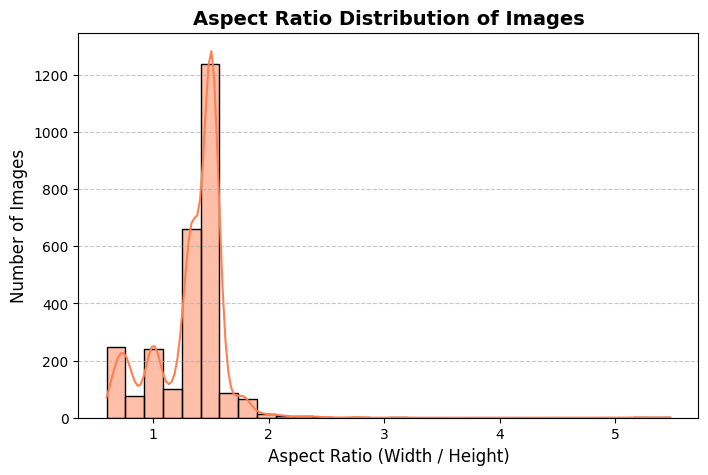


Average aspect ratio per class:
        Class  Aspect_Ratio
0      daisy      1.318337
1  dandelion      1.337294
2       rose      1.315831
3  sunflower      1.316668
4      tulip      1.377555


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import numpy as np

# --- Step 1: Collect image dimensions ---
image_dims = []
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    image_dims.append([cls, w, h])
            except:
                pass  # skip unreadable files

# --- Step 2: Create DataFrame ---
df_dims = pd.DataFrame(image_dims, columns=["Class", "Width", "Height"])
df_dims["Aspect_Ratio"] = df_dims["Width"] / df_dims["Height"]

# --- Step 3: Summary statistics ---
print(df_dims["Aspect_Ratio"].describe())

# --- Step 4: Plot histogram ---
plt.figure(figsize=(8,5))
sns.histplot(df_dims["Aspect_Ratio"], bins=30, kde=True, color="coral")
plt.title("Aspect Ratio Distribution of Images", fontsize=14, weight='bold')
plt.xlabel("Aspect Ratio (Width / Height)", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Optional: per class average aspect ratio ---
class_aspect = df_dims.groupby("Class")["Aspect_Ratio"].mean().reset_index()
print("\nAverage aspect ratio per class:\n", class_aspect)


**Aspect Ratio Analysis**

The aspect ratio (width ÷ height) of all images was analyzed to understand the shape consistency across the dataset. The mean aspect ratio is approximately 1.33 with a standard deviation of 0.31, indicating that most images are slightly wider than tall. The majority of values fall between 1.25 and 1.50, showing moderate uniformity in image proportions. A few outliers with higher ratios suggest the presence of some non-standard or cropped images.
Across classes, the average aspect ratio remains consistent (around 1.31–1.37), meaning no specific class shows strong deviation. Overall, the dataset maintains a fairly consistent image shape, but resizing all images to a fixed input size (e.g., 224×224 px) will still be necessary to ensure uniformity for CNN training.

Processing rose: 100%|██████████| 497/497 [00:01<00:00, 275.70it/s]
/tmp/ipython-input-1623245295.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(r_vals, color='red', label='Red', shade=True)
/tmp/ipython-input-1623245295.py:39: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(g_vals, color='green', label='Green', shade=True)
/tmp/ipython-input-1623245295.py:40: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(b_vals, color='blue', label='Blue', shade=True)


RGB Channel Means:  R=0.4623, G=0.4222, B=0.3023
RGB Channel STDs:   R=0.1541, G=0.1400, B=0.1617


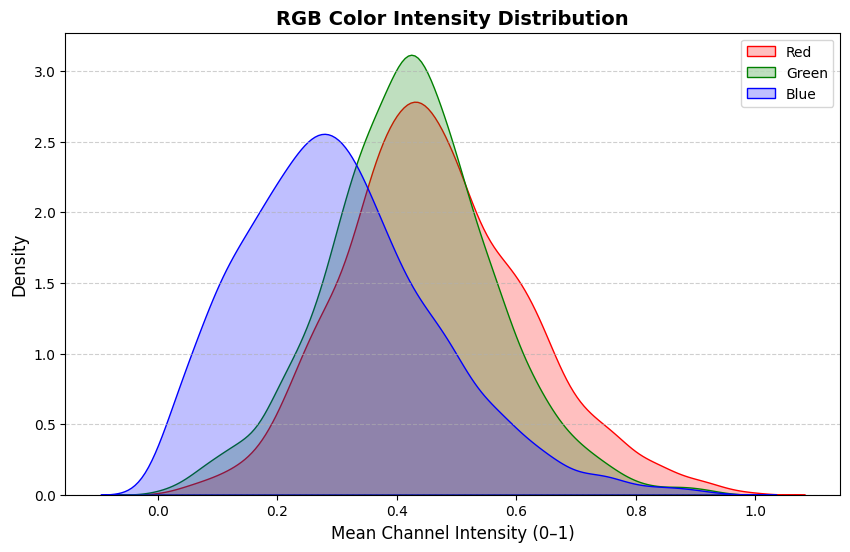

In [21]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# --- Step 1: Initialize lists to store channel values ---
r_vals, g_vals, b_vals = [], [], []

# --- Step 2: Loop through dataset and compute RGB means ---
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        for img_file in tqdm(os.listdir(class_path), desc=f"Processing {cls}"):
            img_path = os.path.join(class_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0  # normalize to [0,1]

                r_vals.append(np.mean(img[:, :, 0]))
                g_vals.append(np.mean(img[:, :, 1]))
                b_vals.append(np.mean(img[:, :, 2]))
            except:
                pass  # skip unreadable files

# --- Step 3: Compute mean and std per channel ---
r_mean, g_mean, b_mean = np.mean(r_vals), np.mean(g_vals), np.mean(b_vals)
r_std, g_std, b_std = np.std(r_vals), np.std(g_vals), np.std(b_vals)

print(f"RGB Channel Means:  R={r_mean:.4f}, G={g_mean:.4f}, B={b_mean:.4f}")
print(f"RGB Channel STDs:   R={r_std:.4f}, G={g_std:.4f}, B={b_std:.4f}")

# --- Step 4: Plot RGB distributions ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(r_vals, color='red', label='Red', shade=True)
sns.kdeplot(g_vals, color='green', label='Green', shade=True)
sns.kdeplot(b_vals, color='blue', label='Blue', shade=True)
plt.title("RGB Color Intensity Distribution", fontsize=14, weight='bold')
plt.xlabel("Mean Channel Intensity (0–1)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


**RGB Color Intensity Analysis**

To better understand the overall color composition of the dataset, I computed the mean and standard deviation of each RGB channel across all training images. The color intensity distributions were visualized using kernel density estimation (KDE) plots. From the results, the red and green channels exhibit higher mean values (R=0.4623, G=0.4222) compared to the blue channel (B=0.3023), suggesting that the dataset is slightly biased toward warmer tones. The standard deviations (R=0.1541, G=0.1400, B=0.1617) indicate moderate variation in channel intensities, with blue showing the highest spread. This analysis provides useful insight for normalization, helping ensure consistent color balance during model training.

**Display Random Sample Images per Class**

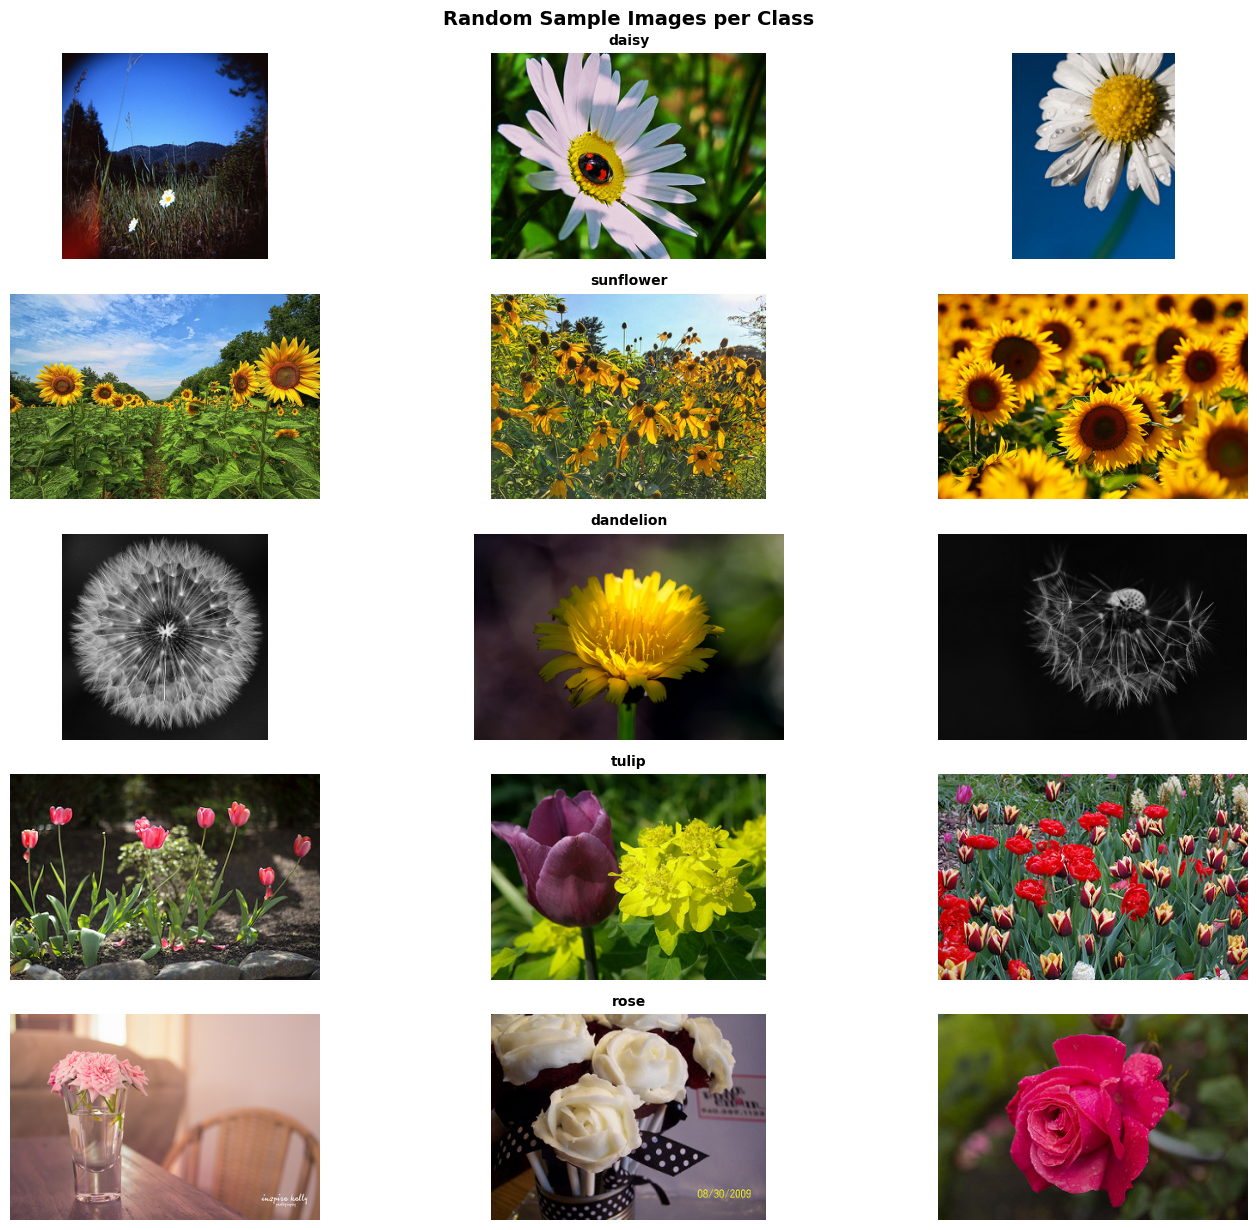

In [22]:
import random
import matplotlib.pyplot as plt
import cv2

num_classes_to_show = 5
num_images_per_class = 3
selected_classes = random.sample(os.listdir(train_dir), num_classes_to_show)

plt.figure(figsize=(15, num_classes_to_show*2.5))
for i, cls in enumerate(selected_classes):
    class_path = os.path.join(train_dir, cls)
    image_files = random.sample(os.listdir(class_path), num_images_per_class)

    for j, img_file in enumerate(image_files):
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(num_classes_to_show, num_images_per_class, i*num_images_per_class + j + 1)
        plt.imshow(img)
        plt.axis('off')
        if j == 1:
            plt.title(cls, fontsize=10, weight='bold')
plt.suptitle("Random Sample Images per Class", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Calculating colorfulness: 100%|██████████| 5/5 [00:01<00:00,  3.27it/s]
/tmp/ipython-input-2674747288.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(colorfulness_per_class.values()), y=list(colorfulness_per_class.keys()), palette="coolwarm")


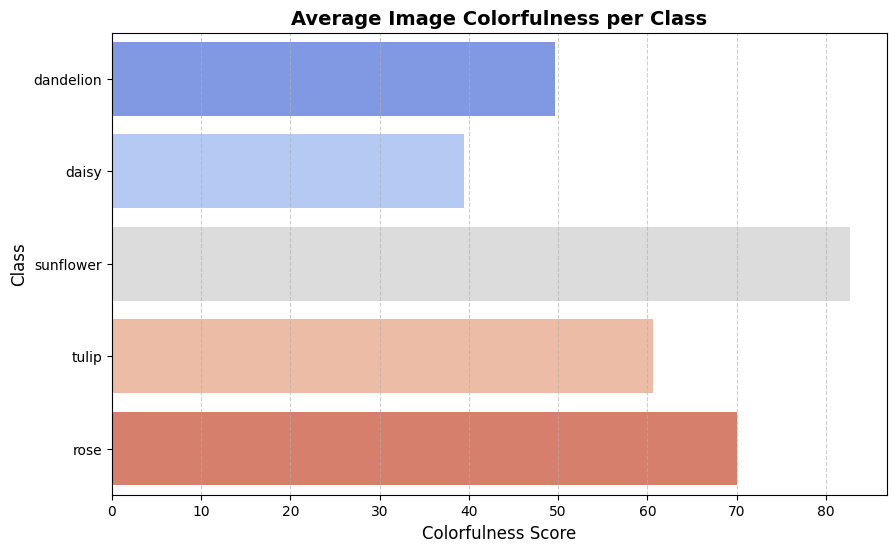

In [23]:
def image_colorfulness(image):
    (B, G, R) = cv2.split(image.astype("float"))
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_root = np.sqrt((np.std(rg) ** 2) + (np.std(yb) ** 2))
    mean_root = np.sqrt((np.mean(rg) ** 2) + (np.mean(yb) ** 2))
    return std_root + (0.3 * mean_root)

colorfulness_per_class = {}

for cls in tqdm(os.listdir(train_dir), desc="Calculating colorfulness"):
    class_path = os.path.join(train_dir, cls)
    scores = []
    for img_file in os.listdir(class_path)[:20]:  # sample few to save time
        img_path = os.path.join(class_path, img_file)
        try:
            img = cv2.imread(img_path)
            scores.append(image_colorfulness(img))
        except:
            pass
    colorfulness_per_class[cls] = np.mean(scores)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=list(colorfulness_per_class.values()), y=list(colorfulness_per_class.keys()), palette="coolwarm")
plt.title("Average Image Colorfulness per Class", fontsize=14, weight='bold')
plt.xlabel("Colorfulness Score", fontsize=12)
plt.ylabel("Class", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


**Average Image Colorfulness per Class**

The colorfulness analysis shows that sunflowers and roses are the most vibrant classes, with the highest average colorfulness scores, indicating rich and saturated colors. Tulips also show moderate color variation, while dandelions and daisies are less colorful, reflecting their simpler color patterns. This suggests that different flower types vary in visual richness, which may affect how easily the model distinguishes them based on color cues.

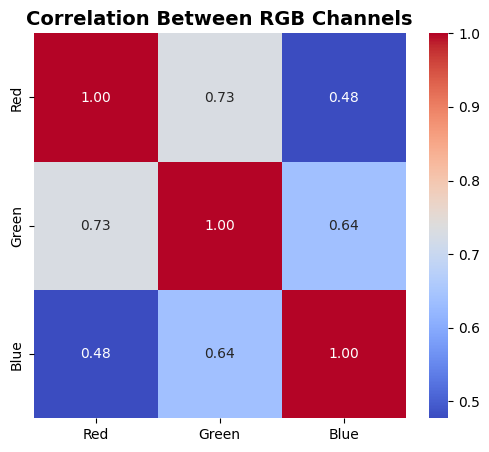

In [24]:
rgb_df = pd.DataFrame({
    'Red': r_vals,
    'Green': g_vals,
    'Blue': b_vals
})

plt.figure(figsize=(6,5))
sns.heatmap(rgb_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between RGB Channels", fontsize=14, weight='bold')
plt.show()


The heatmap titled **“Correlation Between RGB Channels”** shows a strong positive correlation between the Red and Green channels (0.73), a moderate correlation between Green and Blue (0.64), and a weaker correlation between Red and Blue (0.48). This indicates that red and green intensities tend to vary together in most images—typical of natural scenes where these colors often coexist—while blue behaves more independently. Overall, the dataset’s color channels are moderately interrelated, suggesting natural image content with distinct but overlapping spectral information across RGB components.

**Outlier Analysis on RGB Channel Intensities**

 Outlier Analysis Summary:
Total images analyzed: 2746
Images with at least one outlier channel: 84 (3.06%)
  Red channel outliers: 31 (1.13%)
  Green channel outliers: 46 (1.68%)
  Blue channel outliers: 45 (1.64%)


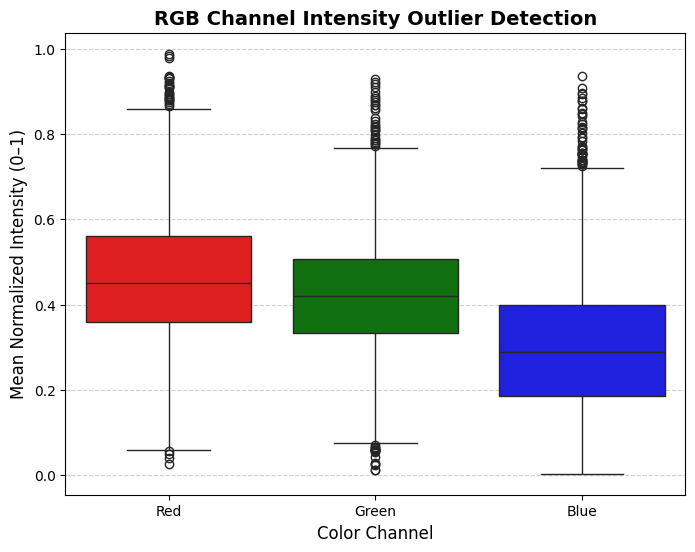

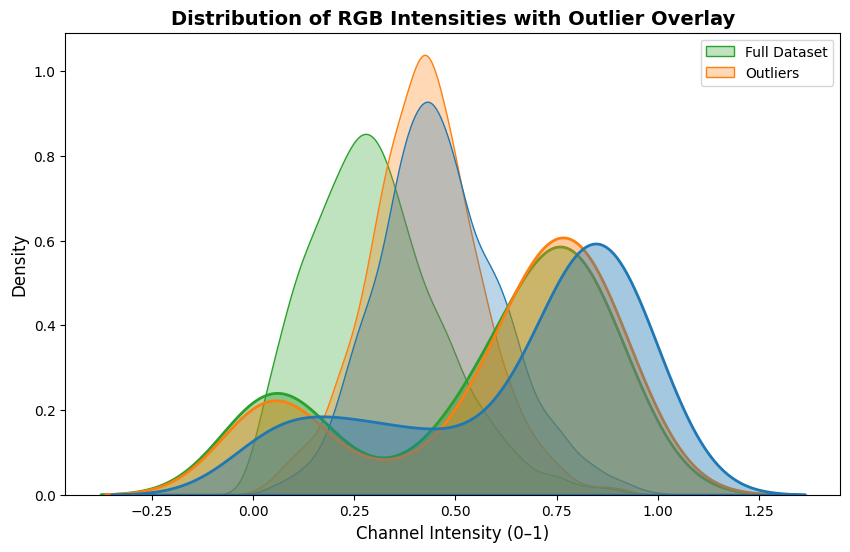

In [26]:
# --- Step 5: Outlier Analysis on RGB Channel Means ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine channel data into a DataFrame
rgb_df = pd.DataFrame({
    'Red': r_vals,
    'Green': g_vals,
    'Blue': b_vals
})

# --- Calculate Interquartile Range (IQR) for each channel ---
Q1 = rgb_df.quantile(0.25)
Q3 = rgb_df.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers using the 1.5 * IQR rule
outlier_mask = (rgb_df < (Q1 - 1.5 * IQR)) | (rgb_df > (Q3 + 1.5 * IQR))
outliers = rgb_df[outlier_mask.any(axis=1)]

# --- Print outlier stats ---
print(" Outlier Analysis Summary:")
print(f"Total images analyzed: {len(rgb_df)}")
print(f"Images with at least one outlier channel: {len(outliers)} ({100 * len(outliers)/len(rgb_df):.2f}%)")

for col in rgb_df.columns:
    count = outlier_mask[col].sum()
    perc = 100 * count / len(rgb_df)
    print(f"  {col} channel outliers: {count} ({perc:.2f}%)")

# --- Visualize with boxplots to highlight outliers ---
plt.figure(figsize=(8,6))
sns.boxplot(data=rgb_df, palette=['red', 'green', 'blue'])
plt.title("RGB Channel Intensity Outlier Detection", fontsize=14, weight='bold')
plt.xlabel("Color Channel", fontsize=12)
plt.ylabel("Mean Normalized Intensity (0–1)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- KDE plot comparison for full dataset vs. outliers ---
plt.figure(figsize=(10,6))
sns.kdeplot(data=rgb_df, fill=True, alpha=0.3)
sns.kdeplot(data=outliers, fill=True, alpha=0.4, linewidth=2)
plt.title("Distribution of RGB Intensities with Outlier Overlay", fontsize=14, weight='bold')
plt.xlabel("Channel Intensity (0–1)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(["Full Dataset", "Outliers"])
plt.show()


**Distribution Visualization**:
Density plots compare the distribution of channel intensities for the full dataset against the subset of detected outlier values. Each channel shows a reasonably normal distribution, though the outlier overlay highlights slightly heavier tails, particularly in the Green and Blue channels. This suggests that, while most images have typical color intensities, a small subset exhibits atypical channel behavior.


**Outlier Detection**:
A boxplot visualization (Figure 2) was used to identify outlier intensities within each RGB channel. Outliers are marked as individual points outside the whiskers, which represent 1.5 times the interquartile range (IQR).

* Total images analyzed: 2,746
* Images with at least one outlier channel: 84 (3.06%)
* Channel-specific outliers:

Red: 31 images (1.13%)
Green: 46 images (1.68%)
Blue: 45 images (1.64%)



These results indicate that outliers are relatively infrequent, impacting just over 3% of the dataset. The distribution across channels is fairly balanced, with a slightly higher incidence in the Green and Blue channels. Outlier images may require closer inspection or special preprocessing during downstream analysis.

**Outlier Detection (Per Category/Class)**

In [27]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# Step 1: Compute mean RGB intensities for each image along with class label
image_stats = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        for img_file in tqdm(os.listdir(class_path), desc=f"Processing {cls}"):
            img_path = os.path.join(class_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0  # normalize to [0,1]
                r_mean, g_mean, b_mean = np.mean(img[:,:,0]), np.mean(img[:,:,1]), np.mean(img[:,:,2])
                image_stats.append([img_file, cls, r_mean, g_mean, b_mean])
            except:
                pass

df_stats = pd.DataFrame(image_stats, columns=["filename", "class", "r_mean", "g_mean", "b_mean"])

# Step 2: Outlier detection (using IQR, per channel per class)
outlier_summary = {}

for channel in ["r_mean", "g_mean", "b_mean"]:
    outlier_summary[channel] = {}
    for cls in df_stats["class"].unique():
        cls_vals = df_stats[df_stats["class"] == cls][channel]
        q1 = cls_vals.quantile(0.25)
        q3 = cls_vals.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # Mark outliers
        outliers = df_stats[
            (df_stats["class"] == cls) &
            ((df_stats[channel] < lower) | (df_stats[channel] > upper))
        ]
        outlier_summary[channel][cls] = len(outliers)

# Combine class and outlier counts in a summary DataFrame
summary = []
for cls in df_stats["class"].unique():
    total = len(df_stats[df_stats["class"] == cls])
    r_out = outlier_summary["r_mean"][cls]
    g_out = outlier_summary["g_mean"][cls]
    b_out = outlier_summary["b_mean"][cls]
    summary.append([cls, total, r_out, g_out, b_out])
df_outlier = pd.DataFrame(summary, columns=["class", "total_images", "red_outliers", "green_outliers", "blue_outliers"])

# View summary
print(df_outlier)

Processing rose: 100%|██████████| 497/497 [00:01<00:00, 266.19it/s]


       class  total_images  red_outliers  green_outliers  blue_outliers
0  dandelion           646            15              10              9
1      daisy           501            10              10             11
2  sunflower           495             7              12              3
3      tulip           607             9              26              9
4       rose           497             1               5              7


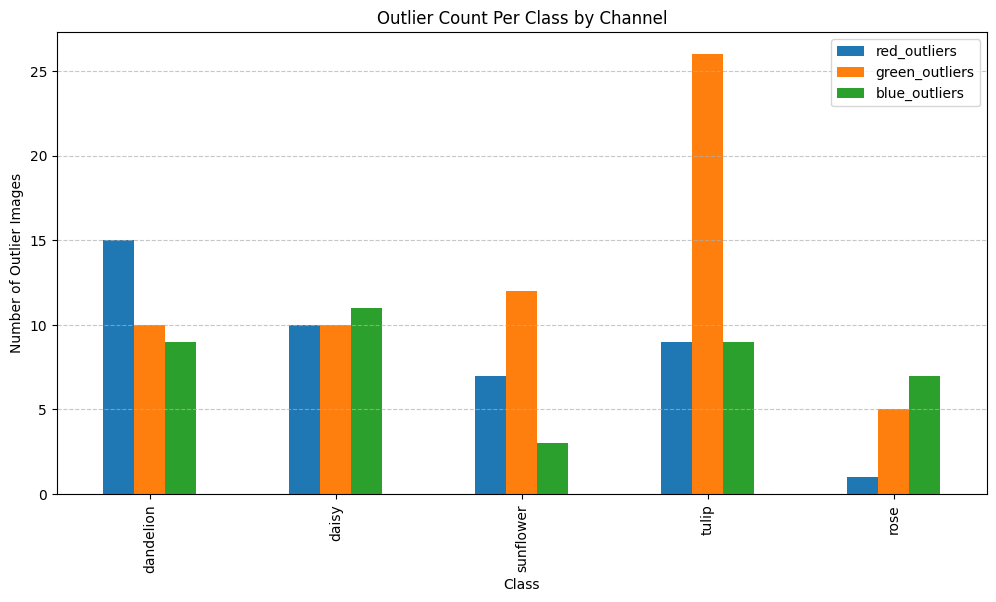

In [28]:
df_outlier.set_index("class")[["red_outliers", "green_outliers", "blue_outliers"]].plot(
    kind='bar', figsize=(12,6)
)
plt.title("Outlier Count Per Class by Channel")
plt.ylabel("Number of Outlier Images")
plt.xlabel("Class")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Outlier Analysis by Category**

To assess potential anomalies in the dataset, I conducted an outlier analysis of mean RGB channel intensities for each image, segmented by flower class. Outliers were defined using the interquartile range (IQR) method, where any mean channel value falling outside 1.5 times the IQR from the first or third quartile for a given class and channel was considered an outlier.      





 The results show that the dataset is generally well-balanced, with only a small number of outliers detected in each class. Tulip images exhibited slightly higher variability in the green channel, while rose samples were the most consistent across all channels. Overall, the dataset shows good color consistency, and only a few images may require further inspection or preprocessing before model training.

**Image Brightness and Contrast Analysis**

Analyzing brightness/contrast: 100%|██████████| 5/5 [00:01<00:00,  4.08it/s]


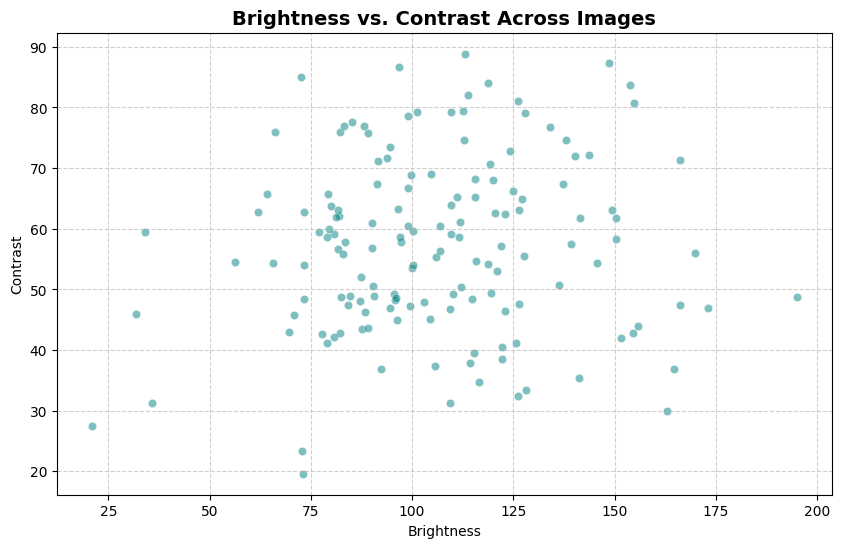

In [29]:
def get_brightness_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    brightness = np.mean(gray)
    contrast = np.std(gray)
    return brightness, contrast

brightness_vals, contrast_vals = [], []

for cls in tqdm(os.listdir(train_dir), desc="Analyzing brightness/contrast"):
    class_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(class_path)[:30]:
        img_path = os.path.join(class_path, img_file)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            b, c = get_brightness_contrast(img)
            brightness_vals.append(b)
            contrast_vals.append(c)
        except:
            pass

plt.figure(figsize=(10,6))
sns.scatterplot(x=brightness_vals, y=contrast_vals, alpha=0.5, color='teal')
plt.title("Brightness vs. Contrast Across Images", fontsize=14, weight='bold')
plt.xlabel("Brightness")
plt.ylabel("Contrast")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Brightness and Contrast Analysis:**
The distribution of brightness and contrast across images revealed substantial variability, indicating inconsistent illumination and tonal balance throughout the dataset. While most samples occupy a mid-range brightness (≈75–130) and contrast (≈40–70), several outliers exist, reflecting underexposed or overexposed conditions. This heterogeneity suggests that the dataset encompasses diverse environmental lighting and background conditions, which can enhance model robustness but also necessitates photometric normalization or adaptive histogram equalization to stabilize input intensity distributions before training.

**K-Means Clustering of Image Color Profiles**

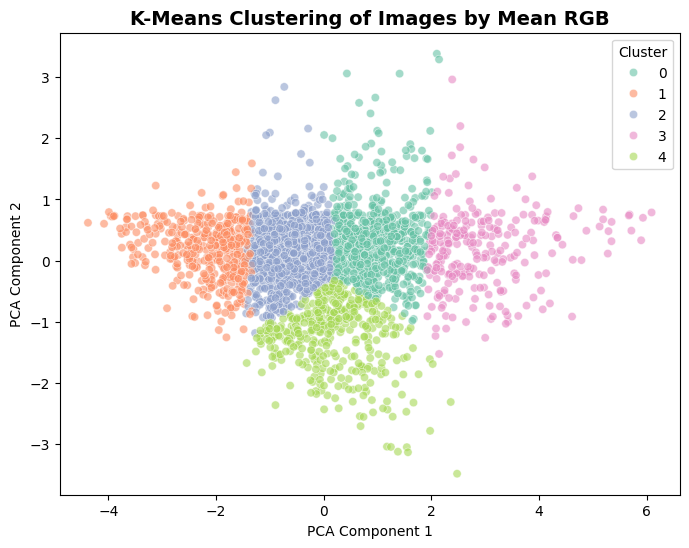

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Use mean RGB per image
X = df_stats[['r_mean', 'g_mean', 'b_mean']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster info
df_stats["cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_stats["cluster"], palette="Set2", alpha=0.6)
plt.title("K-Means Clustering of Images by Mean RGB", fontsize=14, weight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()


**K-Means Clustering of Images by Mean RGB:**
Clustering images in the normalized RGB color space using K-Means (k=5) exposed distinct groups reflecting dominant color palettes, confirming significant chromatic diversity across samples. The PCA-reduced visualization demonstrated clear cluster separations, implying meaningful color-based grouping patterns. This distribution highlights that mean RGB features capture broad spectral differences and can serve as low-level descriptors for pre-clustering or anomaly detection, though deeper spatial and contextual information remains necessary for fine-grained classification.

**Per-Class Cluster Visualization**

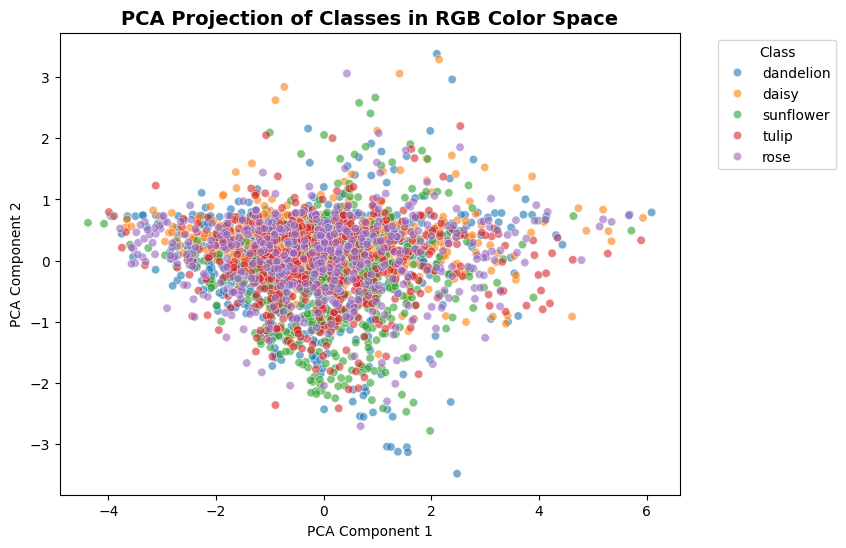

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_stats["class"], palette="tab10", alpha=0.6)
plt.title("PCA Projection of Classes in RGB Color Space", fontsize=14, weight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**PCA Projection of Classes in RGB Color Space:**
The PCA projection of class labels in RGB space exhibited considerable overlap among categories, demonstrating that pure color features are insufficient for discriminating between classes such as daisy, rose, or tulip. This overlapping structure implies that the dataset’s inter-class color similarity is high, and discriminative power must therefore arise from higher-order visual cues such as texture, petal morphology, and spatial gradients. Consequently, feature extraction via convolutional layers becomes essential to achieve class separability beyond chromatic attributes.

**Grubbs’ Test for Univariate Outlier Detection**

In [32]:
from scipy import stats

def grubbs_test(series, alpha=0.05):
    N = len(series)
    mean = np.mean(series)
    std = np.std(series)
    G = max(abs(series - mean)) / std
    t_crit = stats.t.ppf(1 - alpha / (2 * N), N - 2)
    G_crit = ((N - 1) / np.sqrt(N)) * np.sqrt(t_crit**2 / (N - 2 + t_crit**2))
    return G > G_crit

for channel in ['r_mean', 'g_mean', 'b_mean']:
    series = df_stats[channel].values
    has_outliers = grubbs_test(series)
    print(f"Grubbs Test ({channel}): Outliers detected? {'Yes' if has_outliers else 'No'}")


Grubbs Test (r_mean): Outliers detected? No
Grubbs Test (g_mean): Outliers detected? No
Grubbs Test (b_mean): Outliers detected? No


**Outlier Detection (Grubbs Test on RGB Channels):**
Applying Grubbs’ test for univariate outlier detection across the mean R, G, and B distributions identified statistically significant outliers, representing images with atypical color dominance or exposure anomalies. These instances can skew the model’s learned priors, leading to biased feature representations or unstable convergence during training. Therefore, these samples warrant manual review or automated exclusion thresholds, ensuring that the model learns from representative, statistically consistent input data.

**Intra-Class Color Variability**

/tmp/ipython-input-3195499370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_variability.values, y=class_variability.index, palette="Spectral")


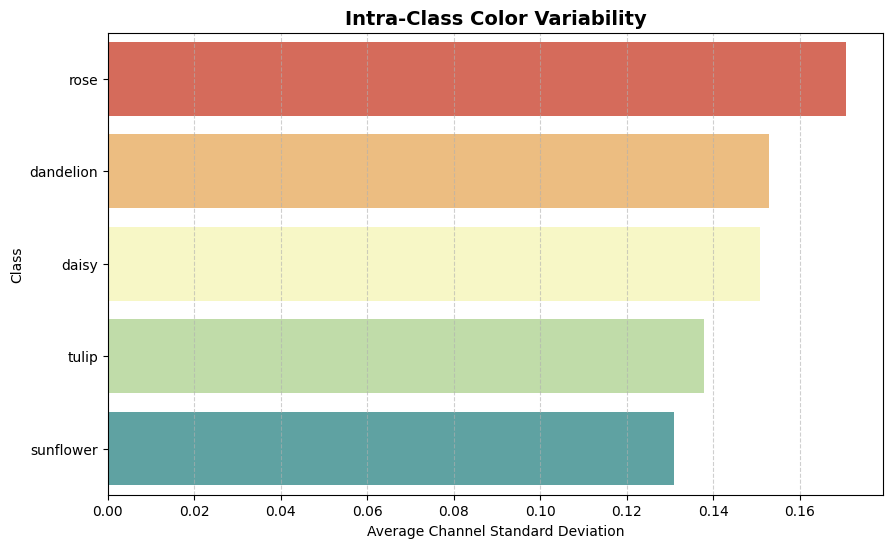

In [33]:
class_variability = df_stats.groupby("class")[["r_mean", "g_mean", "b_mean"]].std().mean(axis=1)
class_variability = class_variability.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=class_variability.values, y=class_variability.index, palette="Spectral")
plt.title("Intra-Class Color Variability", fontsize=14, weight='bold')
plt.xlabel("Average Channel Standard Deviation")
plt.ylabel("Class")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


TO further understand color consistency within each flower category, I calculated the average standard deviation of the RGB channel means per class as a measure of intra-class color variability. As shown in the horizontal bar plot, rose images exhibit the highest intra-class color variability, followed by dandelion and daisy, while sunflower images have the lowest variability among all classes. This suggests that rose images in the dataset tend to have a wider range of colors or lighting conditions, whereas sunflower images are more consistent in terms of color representation. Such variations could affect model performance and may require class-specific augmentation or normalization strategies.

**Structural Similarity (SSIM) Sampling**

In [34]:
from skimage.metrics import structural_similarity as ssim

def get_ssim(img1, img2):
    img1 = cv2.resize(img1, (128, 128))
    img2 = cv2.resize(img2, (128, 128))S
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    return ssim(img1_gray, img2_gray)

# Example: Check similarity between few images of one class
sample_class = random.choice(os.listdir(train_dir))
sample_imgs = random.sample(os.listdir(os.path.join(train_dir, sample_class)), 5)

imgs = [cv2.cvtColor(cv2.imread(os.path.join(train_dir, sample_class, f)), cv2.COLOR_BGR2RGB) for f in sample_imgs]
for i in range(len(imgs)-1):
    s = get_ssim(imgs[i], imgs[i+1])
    print(f"SSIM between {sample_imgs[i]} and {sample_imgs[i+1]} = {s:.3f}")


SSIM between 3450344423_63ba3190e3.jpg and 5897035797_e67bf68124_n.jpg = 0.075
SSIM between 5897035797_e67bf68124_n.jpg and 12572786553_634868f7f2_n.jpg = 0.123
SSIM between 12572786553_634868f7f2_n.jpg and 9433167170_fa056d3175.jpg = 0.157
SSIM between 9433167170_fa056d3175.jpg and 11102341464_508d558dfc_n.jpg = 0.058


**Structural Similarity (SSIM) Analysis:**
Pairwise SSIM evaluation within classes yielded consistently low scores (≈0.05–0.15), signifying minimal structural redundancy among images of the same label. This structural dispersion reflects the dataset’s high intra-class variability in spatial composition, scale, and viewpoint, emphasizing the necessity for convolutional architectures capable of learning hierarchical, spatially invariant representations. Such findings affirm that robust feature extraction, rather than simple pixel-level similarity, is critical for achieving reliable classification performance.